AIM:

To implement a Single Layer Perceptron for binary logic gates (AND and OR) and improve the model accuracy. Also, to train the perceptron on a random dataset, make predictions, and evaluate its accuracy.

In [1]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
def step_function(x):
    return 1 if x >= 0 else 0

# Perceptron Class
class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):
            for i in range(len(X)):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = step_function(linear_output)
                error = y[i] - prediction

                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error

    def predict(self, X):
        predictions = []

        for sample in X:
            linear_output = np.dot(sample, self.weights) + self.bias
            predictions.append(step_function(linear_output))

        return np.array(predictions)

In [3]:
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

and_model = Perceptron(learning_rate=0.1, epochs=20)
and_model.fit(X_and, y_and)

and_prediction = and_model.predict(X_and)

print("AND Gate")
print("Predictions:", and_prediction)
print("Accuracy:", accuracy_score(y_and, and_prediction))

print("AND Gate Results")
print("Input\tExpected\tPredicted")

for x, y_true, y_pred in zip(X_and, y_and, and_prediction):
    print(f"{x}\t{y_true}\t\t{y_pred}")

print("\n----- Improving the AND Model -----")

# Improved model
improved_and = Perceptron(learning_rate=0.05, epochs=100)
improved_and.fit(X_and, y_and)

improved_prediction = improved_and.predict(X_and)

print("Improved Predictions:", improved_prediction)
print("Improved Accuracy:", accuracy_score(y_and, improved_prediction))

# -------------------- OR Gate --------------------

X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

# Increased epochs to improve accuracy
or_model = Perceptron(learning_rate=0.05, epochs=30)

or_model.fit(X_or, y_or)

or_prediction = or_model.predict(X_or)

print("\nOR Gate")
print("Predictions:", or_prediction)
print("Accuracy:", accuracy_score(y_or, or_prediction))

print("\nOR Gate Results")
print("Input\tExpected\tPredicted")

for x, y_true, y_pred in zip(X_or, y_or, or_prediction):
    print(f"{x}\t{y_true}\t\t{y_pred}")

print("\n----- Improving the OR Model -----")

improved_or = Perceptron(learning_rate=0.05, epochs=100)
improved_or.fit(X_or, y_or)

improved_prediction = improved_or.predict(X_or)

print("Improved Predictions:", improved_prediction)
print("Improved Accuracy:", accuracy_score(y_or, improved_prediction))

AND Gate
Predictions: [0 0 0 1]
Accuracy: 1.0
AND Gate Results
Input	Expected	Predicted
[0 0]	0		0
[0 1]	0		0
[1 0]	0		0
[1 1]	1		1

----- Improving the AND Model -----
Improved Predictions: [0 0 0 1]
Improved Accuracy: 1.0

OR Gate
Predictions: [0 1 1 1]
Accuracy: 1.0

OR Gate Results
Input	Expected	Predicted
[0 0]	0		0
[0 1]	1		1
[1 0]	1		1
[1 1]	1		1

----- Improving the OR Model -----
Improved Predictions: [0 1 1 1]
Improved Accuracy: 1.0


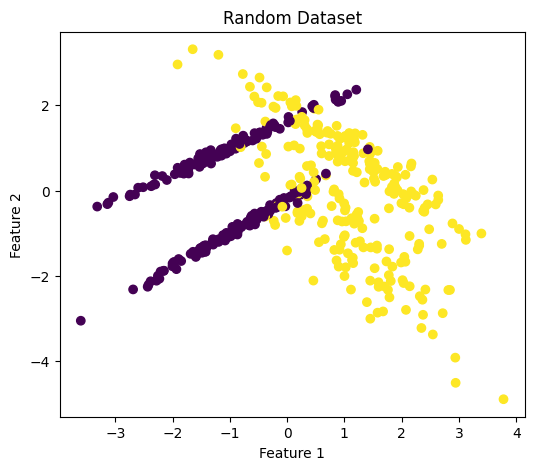

Random Dataset Results
Model Accuracy: 0.84


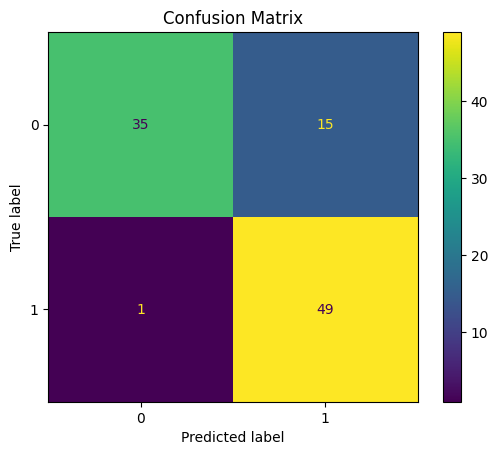

Weights: [0.03258598 0.00847605]
Bias: 0.009999999999999997


In [4]:
# Generate Random Dataset
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1], c=y)

plt.title("Random Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = Perceptron(learning_rate=0.01, epochs=100)

model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Random Dataset Results")
print("Model Accuracy:", accuracy)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")

plt.show()

# Display learned parameters
print("Weights:", model.weights)
print("Bias:", model.bias)

Conclusion:

The Single Layer Perceptron was successfully implemented and trained for the AND and OR logic gates. The model correctly classified both logic gates with high accuracy after adjusting the learning rate and number of epochs. The perceptron was also trained on a randomly generated dataset, where it achieved good classification accuracy. This experiment demonstrated the working of the Perceptron Learning Algorithm for binary classification problems.